In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/lorettahayford/avocado/Avoacdo.csv


# 🥑 Avocado Price & Sales Analysis

## Business Problem
This project analyzes historical avocado price and sales data across the United States to uncover patterns in pricing, demand, and regional performance.

## Objective
To provide data-driven recommendations for optimizing pricing strategies, improving inventory planning, and maximizing revenue.

## Dataset
- Source: Kaggle
- Dataset: Avocado Prices (Justin Kiggins)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Styling
sns.set(style="whitegrid")

In [3]:
df = pd.read_csv ('/kaggle/input/datasets/lorettahayford/avocado/Avoacdo.csv')
df.head()

,X,Date,AveragePrice,Total.Volume.x,X4046,X4225,X4770,Total.Bags,Small.Bags,Large.Bags,XLarge.Bags,type,year,region,Total.Volume.y
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany,16067799.97
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany,16067799.97
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany,16067799.97
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany,16067799.97
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany,16067799.97


## Data Overview

The dataset includes:
- Date
- Average Price
- Total Volume
- Avocado type (Organic vs Conventional)
- Region
- PLU codes (different avocado sizes)

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   X               18249 non-null  int64  
 1   Date            18249 non-null  object 
 2   AveragePrice    18249 non-null  float64
 3   Total.Volume.x  18249 non-null  float64
 4   X4046           18249 non-null  float64
 5   X4225           18249 non-null  float64
 6   X4770           18249 non-null  float64
 7   Total.Bags      18249 non-null  float64
 8   Small.Bags      18249 non-null  float64
 9   Large.Bags      18249 non-null  float64
 10  XLarge.Bags     18249 non-null  float64
 11  type            18249 non-null  object 
 12  year            18249 non-null  int64  
 13  region          18249 non-null  object 
 14  Total.Volume.y  18249 non-null  float64
dtypes: float64(10), int64(2), object(3)
memory usage: 2.1+ MB


,X,AveragePrice,Total.Volume.x,X4046,X4225,X4770,Total.Bags,Small.Bags,Large.Bags,XLarge.Bags,year,Total.Volume.y
count,18249.000000,18249.000000,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000,18249.000000,1.824900e+04
mean,24.232232,1.405978,8.506440e+05,2.930084e+05,2.951546e+05,2.283974e+04,2.396392e+05,1.821947e+05,5.433809e+04,3106.426507,2016.147899,2.874939e+08
std,15.481045,0.402677,3.453545e+06,1.264989e+06,1.204120e+06,1.074641e+05,9.862424e+05,7.461785e+05,2.439660e+05,17692.894652,0.939938,8.101471e+08
min,0.000000,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2015.000000,1.094267e+07
25%,10.000000,1.100000,1.083858e+04,8.540700e+02,3.008780e+03,0.000000e+00,5.088640e+03,2.849420e+03,1.274700e+02,0.000000,2015.000000,3.555554e+07
50%,24.000000,1.370000,1.073768e+05,8.645300e+03,2.906102e+04,1.849900e+02,3.974383e+04,2.636282e+04,2.647710e+03,0.000000,2016.000000,7.153289e+07
75%,38.000000,1.660000,4.329623e+05,1.110202e+05,1.502069e+05,6.243420e+03,1.107834e+05,8.333767e+04,2.202925e+04,132.500000,2017.000000,1.956433e+08
max,52.000000,3.250000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,2018.000000,5.864740e+09


## Data Cleaning

Steps:
- Convert date column to datetime format
- Remove duplicates
- Handle missing values
- Standardize column names

In [5]:
df.columns = df.columns.str.strip().str.lower()

In [6]:
df.columns

Index(['x', 'date', 'averageprice', 'total.volume.x', 'x4046', 'x4225',
       'x4770', 'total.bags', 'small.bags', 'large.bags', 'xlarge.bags',
       'type', 'year', 'region', 'total.volume.y'],
      dtype='object')

In [7]:
df.columns[df.columns.duplicated()]

Index([], dtype='object')

In [8]:
df = df.loc[:, ~df.columns.duplicated()]

In [9]:
df['date'] = pd.to_datetime(df['date'])

In [10]:
# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace('.', '_')

# Remove duplicate columns
df = df.loc[:, ~df.columns.duplicated()]

# Convert date
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Drop unnecessary column
df.drop(columns=['x'], inplace=True, errors='ignore')

# Rename columns
df.rename(columns={
    'total_volume_x': 'total_volume',
    'total_volume_y': 'total_volume_check'
}, inplace=True)

# Remove duplicates (rows)
df = df.drop_duplicates()

df.head()

,date,averageprice,total_volume,x4046,x4225,x4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region,total_volume_check
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany,16067799.97
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany,16067799.97
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany,16067799.97
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany,16067799.97
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany,16067799.97


## ⚙️ Feature Engineering

We extract time-based features to analyze trends:
- Month
- Day
- Year (already exists)

In [11]:
df['Month'] = df['date'].dt.month
df['Day'] = df['date'].dt.day

## Exploratory Data Analysis

We analyze:
- Price trends over time
- Price vs demand relationship
- Regional sales performance
- Organic vs conventional comparison

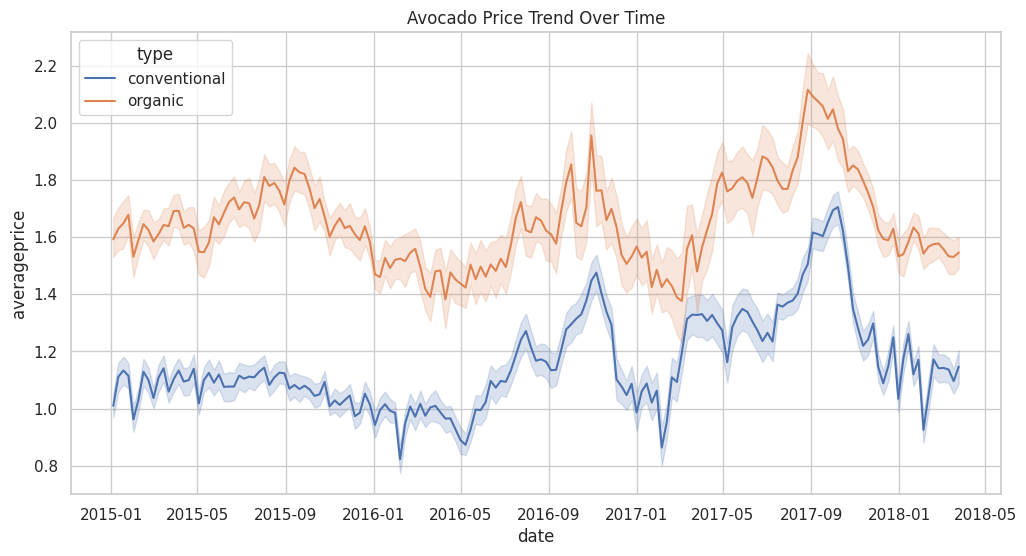

In [12]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='date', y='averageprice', hue='type')
plt.title('Avocado Price Trend Over Time')
plt.show()

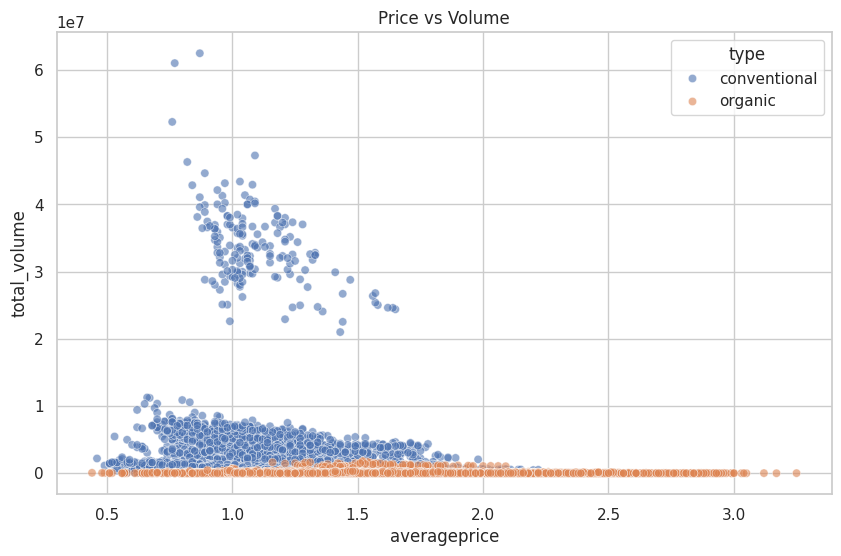

In [13]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='averageprice', y='total_volume', hue='type', alpha=0.6)
plt.title('Price vs Volume')
plt.show()

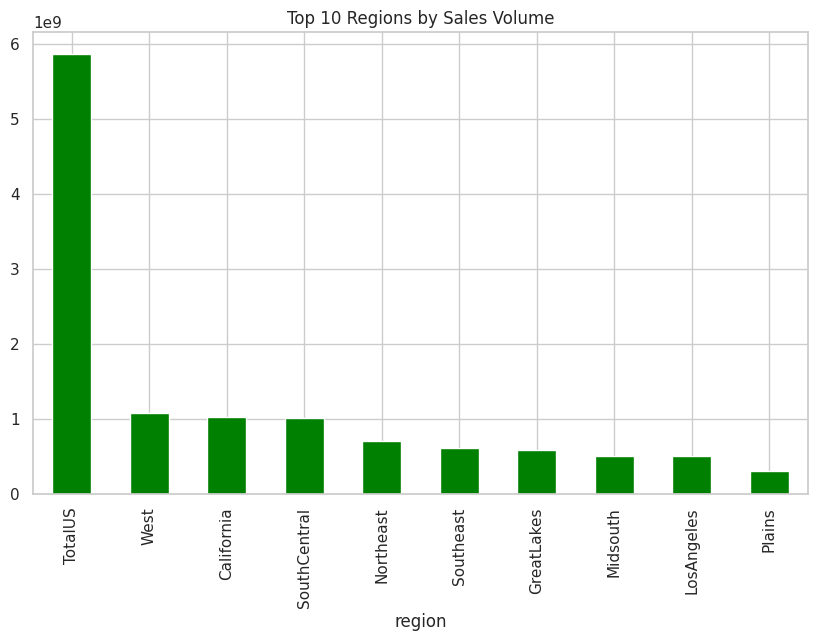

In [14]:
region_sales = df.groupby('region')['total_volume'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
region_sales.plot(kind='bar', color='green')
plt.title('Top 10 Regions by Sales Volume')
plt.show()

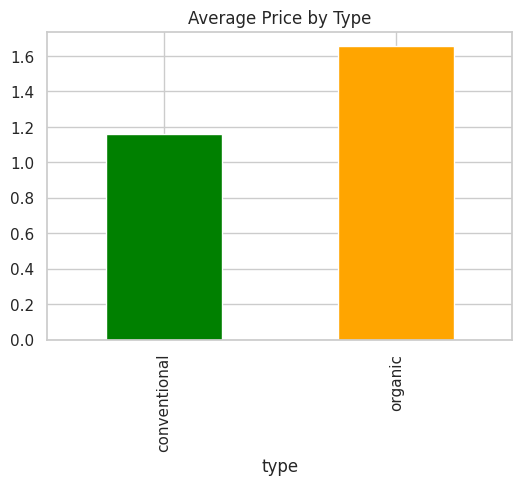

In [15]:
type_price = df.groupby('type')['averageprice'].mean()

plt.figure(figsize=(6,4))
type_price.plot(kind='bar', color=['green', 'orange'])
plt.title('Average Price by Type')
plt.show()

## 📊 Key Insights

- 📉 Higher prices are associated with lower sales volume
- 🌱 Organic avocados are more expensive but sell less volume
- 🌍 Certain regions dominate avocado consumption
- 📅 Prices fluctuate seasonally, indicating predictable demand cycles

## 💡 Business Recommendations

- Implement dynamic pricing strategies based on demand
- Increase supply in high-performing regions
- Promote organic avocados through targeted marketing
- Use seasonal trends for inventory planning

## ✅ Conclusion

This analysis highlights the importance of pricing, region, and seasonality in driving avocado sales. By leveraging these insights, businesses can optimize their strategies and improve profitability.

---